In [7]:

!pip install lpips
!pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.8 MB/s eta 0:00:00


# **NeRF Implementation**

In [8]:
####################
# This cell clones the project repository from GitHub so the notebook can run
# without relying on Google Drive paths.
####################
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/naomi-helmbold/3DReconstruction_DLProject"
REPO_ROOT = Path("/content/3DReconstruction_DLProject")

if not REPO_ROOT.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
else:
    print(f"Using existing repository at {REPO_ROOT}")

DATA_ROOT = REPO_ROOT / "data"
print("Repository root:", REPO_ROOT)
print("Data root:", DATA_ROOT)

Using existing repository at /content/3DReconstruction_DLProject
Repository root: /content/3DReconstruction_DLProject
Data root: /content/3DReconstruction_DLProject/data


## 1. Environment Setup and Configuration

In [9]:
####################
# This cell sets up the environment by importing necessary libraries,
# configuring global parameters like random seeds, device (CPU/GPU),
# and NeRF-specific hyperparameters. Dataset-specific values are selected
# later by executing one of the dataset cells below.
####################
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import trange
import matplotlib.pyplot as plt

# --- Global Configuration and Setup ---

# Set random seeds for reproducibility across different runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Determine the device to use (CUDA if available, otherwise CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# NeRF model and training configuration hyperparameters
CONFIG = {
    "resize_factor": 2,
    "near": 2.0,
    "far": 10.0,
    "n_samples": 64,
    "n_importance": 64,
    "n_rand": 2048 if DEVICE.type == "cuda" else 512,
    "hidden_dim": 256,
    "n_layers": 8,
    "skip_layer": 4,
    "L_pos": 10,
    "L_dir": 4,
    "lr": 5e-4,
    "max_steps": 4000 if DEVICE.type == "cuda" else 600,
    "log_every": 50
}

DATASET_NAME = None
DATASET_KIND = None
DATASET_SOURCE = None
TRAIN_JSON = None
TEST_JSON = None

def select_dataset(name, kind, source_path, resize_factor, train_json=None, test_json=None):
    """Selects the dataset to load later in the notebook."""
    global DATASET_NAME, DATASET_KIND, DATASET_SOURCE, TRAIN_JSON, TEST_JSON

    DATASET_NAME = name
    DATASET_KIND = kind
    DATASET_SOURCE = Path(source_path)
    TRAIN_JSON = Path(train_json) if train_json is not None else None
    TEST_JSON = Path(test_json) if test_json is not None else None
    CONFIG["resize_factor"] = resize_factor

    print("Selected dataset:", DATASET_NAME)
    print("Dataset kind:", DATASET_KIND)
    print("Dataset source:", DATASET_SOURCE)
    print("Resize factor:", CONFIG["resize_factor"])
    if TRAIN_JSON is not None:
        print("Train JSON:", TRAIN_JSON)
    if TEST_JSON is not None:
        print("Test JSON:", TEST_JSON)


print(CONFIG)


# --- Utility Functions for Dataset Loading ---

def qvec2rotmat(qvec):
    """Converts a quaternion vector (w, x, y, z) to a 3x3 rotation matrix."""
    qvec = np.asarray(qvec, dtype=np.float64)
    w, x, y, z = qvec
    return np.array([
        [1.0 - 2.0 * (y * y + z * z), 2.0 * (x * y - z * w), 2.0 * (x * z + y * w)],
        [2.0 * (x * y + z * w), 1.0 - 2.0 * (x * x + z * z), 2.0 * (y * z - x * w)], # Fix: Corrected the third element
        [2.0 * (x * z - y * w), 2.0 * (y * z + x * w), 1.0 - 2.0 * (x * x + y * y)]
    ], dtype=np.float32)

def camera_to_intrinsics(model_name, params):
    """Extracts focal length and principal point from COLMAP camera model parameters."""
    model_name = model_name.upper()
    params = [float(p) for p in params]
    if model_name == "SIMPLE_PINHOLE":
        focal, cx, cy = params[:3]
        fx = fy = focal
        return fx, fy, cx, cy
    if model_name == "PINHOLE":
        fx, fy, cx, cy = params[:4]
        return fx, fy, cx, cy
    if model_name in {"SIMPLE_RADIAL", "RADIAL"}:
        focal, cx, cy = params[:3]
        return focal, focal, cx, cy
    if model_name in {"OPENCV", "OPENCV_FISHEYE"}:
        fx, fy, cx, cy = params[:4]
        return fx, fy, cx, cy
    raise ValueError(f"Unsupported camera model: {model_name}")

def resolve_image_path(base_dir, image_name):
    """Tries to find an image file within specified candidate paths or recursively."""
    candidates = [
        base_dir / image_name,
        base_dir / "salle-entiere" / image_name,
        base_dir / "images" / image_name,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    # Fallback to recursive glob if not found in standard locations
    matches = list(base_dir.rglob(image_name))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Image not found: {image_name}")

def resize_intrinsics(fx, fy, cx, cy, original_width, original_height, target_width, target_height):
    """Adjusts camera intrinsic parameters based on image resizing."""
    scale_x = target_width / original_width
    scale_y = target_height / original_height
    fx *= scale_x
    fy *= scale_y
    cx *= scale_x
    cy *= scale_y
    return fx, fy, cx, cy

def load_json_dataset(json_path, resize_factor=1):
    """Loads dataset from a NeRF-style JSON file (transforms.json)."""
    with open(json_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    H = int(meta["h"])
    W = int(meta["w"])
    # Extract focal lengths and principal points, with defaults if not present
    fx = float(meta.get("fl_x", meta.get("focal", 1.0)))
    fy = float(meta.get("fl_y", fx))
    cx = float(meta.get("cx", W * 0.5))
    cy = float(meta.get("cy", H * 0.5))

    images, poses, intrinsics, camera_ids = [], [], [], []
    base_dir = Path(json_path).parent

    # Iterate through each frame (image and its pose)
    for frame_idx, frame in enumerate(meta["frames"]):
        # Correctly handle file_path: if it starts with '/', treat it as relative to base_dir
        relative_file_path = Path(frame["file_path"])
        if str(relative_file_path).startswith('/'):
            relative_file_path = Path(str(relative_file_path)[1:]) # Remove leading slash
        img_path = base_dir / relative_file_path

        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        # Load image, convert to RGBA, and resize if necessary
        img = Image.open(img_path).convert("RGBA")
        if resize_factor > 1:
            img = img.resize((W // resize_factor, H // resize_factor), Image.Resampling.LANCZOS)

        # Convert image to numpy array, normalize, and composite with alpha
        arr = np.array(img).astype(np.float32) / 255.0
        rgb = arr[..., :3]
        alpha = arr[..., 3:4]
        rgb = rgb * alpha + (1.0 - alpha) # Alpha compositing for transparent backgrounds

        images.append(rgb)
        poses.append(np.array(frame["transform_matrix"], dtype=np.float32))
        intrinsics.append([fx, fy, cx, cy])
        camera_ids.append(frame_idx)

    # Convert lists to torch tensors
    images = torch.from_numpy(np.stack(images, axis=0))
    poses = torch.from_numpy(np.stack(poses, axis=0))
    intrinsics = torch.tensor(intrinsics, dtype=torch.float32)
    camera_ids = torch.tensor(camera_ids, dtype=torch.long)

    # Adjust H, W, and intrinsics for the new resized dimensions
    original_W, original_H = W, H
    H //= resize_factor
    W //= resize_factor
    fx, fy, cx, cy = resize_intrinsics(fx, fy, cx, cy, original_W, original_H, W, H)

    return images, poses, intrinsics, camera_ids, H, W

def load_colmap_dataset(colmap_root, resize_factor=1):
    """Loads dataset from COLMAP output files (cameras.txt, images.txt)."""
    cameras_path = Path(colmap_root) / "cameras.txt"
    images_path = Path(colmap_root) / "images.txt"
    if not cameras_path.exists() or not images_path.exists():
        raise FileNotFoundError("COLMAP dataset needs cameras.txt and images.txt")

    # Read and parse cameras.txt
    camera_lines = []
    for raw_line in cameras_path.read_text(encoding="utf-8").splitlines():
        stripped = raw_line.strip()
        if stripped and not stripped.startswith("#"):
            camera_lines.append(stripped)

    cameras = {}
    all_camera_sizes = [] # Collect all camera sizes
    for line in camera_lines:
        parts = line.split()
        camera_id = int(parts[0])
        model_name = parts[1]
        width = int(parts[2])
        height = int(parts[3])
        params = list(map(float, parts[4:]))
        fx, fy, cx, cy = camera_to_intrinsics(model_name, params)
        cameras[camera_id] = {
            "model": model_name,
            "width": width,
            "height": height,
            "fx": fx,
            "fy": fy,
            "cx": cx,
            "cy": cy,
        }
        all_camera_sizes.append((width, height))

    # Determine a common target resolution if multiple sizes are found
    unique_camera_sizes = sorted(list(set(all_camera_sizes)))
    target_width, target_height = -1, -1

    if len(unique_camera_sizes) > 1: # If multiple sizes, pick the smallest resolution to avoid upsampling.
        target_width = min(s[0] for s in unique_camera_sizes)
        target_height = min(s[1] for s in unique_camera_sizes)
        print(f"Multiple camera resolutions found: {unique_camera_sizes}. All images will be resized to {target_width}x{target_height}.")
    elif len(unique_camera_sizes) == 1:
        target_width, target_height = unique_camera_sizes[0]
    else:
        raise ValueError("No camera definitions found in cameras.txt.")


    # Read and parse images.txt
    images_lines = []
    for raw_line in images_path.read_text(encoding="utf-8").splitlines():
        stripped = raw_line.strip()
        if stripped and not stripped.startswith("#"):
            images_lines.append(stripped)

    if len(images_lines) % 2 != 0:
        raise ValueError("images.txt should contain image header lines paired with 2D point lines")

    base_dir = Path(colmap_root)
    records = []
    # Process image header lines (every other line)
    for i in range(0, len(images_lines), 2):
        header = images_lines[i]
        parts = header.split()
        if len(parts) < 10:
            continue # Skip malformed lines
        image_id = int(parts[0])
        qvec = np.array(list(map(float, parts[1:5])), dtype=np.float32) # Quaternion for rotation
        tvec = np.array(list(map(float, parts[5:8])), dtype=np.float32) # Translation vector
        camera_id = int(parts[8])
        image_name = " ".join(parts[9:])
        camera = cameras[camera_id]
        records.append({
            "image_id": image_id,
            "qvec": qvec,
            "tvec": tvec,
            "camera_id": camera_id,
            "image_name": image_name,
            "fx": camera["fx"],
            "fy": camera["fy"],
            "cx": camera["cx"],
            "cy": camera["cy"],
            "width": camera["width"],
            "height": camera["height"],
            "model": camera["model"],
        })

    records.sort(key=lambda item: item["image_id"]) # Sort records by image ID

    images, poses, intrinsics_list, camera_ids = [], [], [], [] # Renamed intrinsics to intrinsics_list
    skipped_images = []
    for record in records:
        try:
            img_path = resolve_image_path(base_dir, record["image_name"])
        except FileNotFoundError:
            skipped_images.append(record["image_name"])
            continue

        # Load image
        img = Image.open(img_path).convert("RGBA")

        current_img_width, current_img_height = img.size

        # First, resize image to the determined common target_width and target_height
        # And adjust intrinsics accordingly
        if (current_img_width, current_img_height) != (target_width, target_height):
            img = img.resize((target_width, target_height), Image.Resampling.LANCZOS)
            # Adjust intrinsics relative to this first resize
            scaled_fx, scaled_fy, scaled_cx, scaled_cy = resize_intrinsics(
                record["fx"], record["fy"], record["cx"], record["cy"],
                record["width"], record["height"], # Original camera width/height
                target_width, target_height       # New common target width/height
            )
        else:
            scaled_fx, scaled_fy, scaled_cx, scaled_cy = record["fx"], record["fy"], record["cx"], record["cy"]

        # Now, apply the global resize_factor from CONFIG (if any) to the *already common-sized* image
        if resize_factor > 1:
            img = img.resize((target_width // resize_factor, target_height // resize_factor), Image.Resampling.LANCZOS)
            # Adjust intrinsics again by the global resize_factor
            scaled_fx /= resize_factor
            scaled_fy /= resize_factor
            scaled_cx /= resize_factor
            scaled_cy /= resize_factor

        arr = np.array(img).astype(np.float32) / 255.0
        rgb = arr[..., :3]
        alpha = arr[..., 3:4]
        rgb = rgb * alpha + (1.0 - alpha)
        images.append(rgb)

        rot = qvec2rotmat(record["qvec"])
        c2w = np.eye(4, dtype=np.float32)
        c2w[:3, :3] = rot.T
        c2w[:3, 3] = -rot.T @ record["tvec"]
        c2w[:3, 1:3] *= -1.0 # Adjust coordinate system convention
        poses.append(c2w)

        intrinsics_list.append([scaled_fx, scaled_fy, scaled_cx, scaled_cy]) # Use scaled intrinsics
        camera_ids.append(record["camera_id"])

    if not images:
        raise RuntimeError("No COLMAP images were loaded successfully")

    # Convert lists to torch tensors
    images = torch.from_numpy(np.stack(images, axis=0))
    poses = torch.from_numpy(np.stack(poses, axis=0))
    intrinsics = torch.tensor(intrinsics_list, dtype=torch.float32) # Use intrinsics_list
    camera_ids = torch.tensor(camera_ids, dtype=torch.long)

    # Final H and W will be target_height and target_width after global resize_factor
    final_width = target_width // resize_factor
    final_height = target_height // resize_factor

    print(f"Parsed {len(cameras)} COLMAP cameras and {len(records)} registered images")
    if skipped_images:
        preview = ", ".join(skipped_images[:5])
        suffix = "" if len(skipped_images) <= 5 else f" ... (+{len(skipped_images) - 5} more)"
        print(f"Skipped {len(skipped_images)} missing images: {preview}{suffix}")
    print(f"Camera models: {sorted(set(camera['model'] for camera in cameras.values()))}")
    print(f"Loaded image size: {final_height}x{final_width}")
    return images, poses, intrinsics, camera_ids, final_height, final_width

def load_llff_dataset(llff_root, resize_factor=1):
    """Loads dataset from LLFF format (poses_bounds.npy and images_4 folder)."""
    poses_bounds_path = llff_root / "poses_bounds.npy"
    if not poses_bounds_path.exists():
        raise FileNotFoundError(f"LLFF dataset requires poses_bounds.npy in {llff_root}")

    # Load poses and bounds
    poses_bounds = np.load(poses_bounds_path)
    poses = poses_bounds[:, :-2].reshape(-1, 3, 5) # N x 3 x 5 (R, t, hwf)
    bounds = poses_bounds[:, -2:] # N x 2 (near, far)

    # Reformat poses from LLFF to NeRF convention (colmap / opencv)
    # LLFF poses are [R|t] with R_col0 up, R_col1 right, R_col2 back
    # NeRF poses are [R|t] with R_col0 right, R_col1 down, R_col2 forward
    # Also, NeRF c2w should be world to camera, and LLFF is camera to world
    c2w = poses[:, :3, :4] # Extract rotation and translation, shape (N, 3, 4)

    # The following transformation converts LLFF camera-to-world (c2w) to the desired NeRF c2w
    # This involves swapping and negating axes to match coordinate conventions.
    c2w = np.concatenate([c2w[:, :, 1:2], -c2w[:, :, :1], c2w[:, :, 2:]], 2) # Swap X and Y, negate new X
    # The problematic line. It should include the translation column (index 3)
    c2w = c2w[:, :, [1,0,2,3]] # Fix: Added index 3 to retain the translation column
    c2w[:, :, 2] *= -1 # Negate Z
    c2w = np.concatenate([c2w, np.broadcast_to(np.array([0.,0.,0.,1.], dtype=np.float32)[None,None,:], c2w[:,:1,:4].shape)], axis=1) # Add last row

    hwf = poses[:, :3, 4] # H, W, Focal length
    H, W, f = hwf[0].tolist()

    # Load images
    image_dir = llff_root / f"images_{resize_factor}" # Expects pre-downsampled images
    if not image_dir.exists():
        # Fallback to original images if pre-downsampled not found
        image_dir = llff_root / "images_8"
        if not image_dir.exists():
            raise FileNotFoundError(f"LLFF images directory not found: {image_dir}")

    image_paths = sorted(list(image_dir.iterdir()))
    if not image_paths:
        raise FileNotFoundError(f"No images found in {image_dir}")

    images_list = []
    skipped_images = [] # Initialize skipped_images list here for LLFF
    for img_path in image_paths:
        if img_path.suffix.lower() in [".jpg", ".png", ".jpeg"]:
            try:
                img = Image.open(img_path).convert("RGBA")
            except Image.UnidentifiedImageError:
                print(f"Warning: Unidentified image file '{img_path}'. Skipping this image.")
                skipped_images.append(str(img_path))
                continue
            # Resize if necessary (if images_4 wasn't used)
            if resize_factor > 1 and f"images_{resize_factor}" not in str(image_dir):
                img = img.resize((W // resize_factor, H // resize_factor), Image.Resampling.LANCZOS)

            arr = np.array(img).astype(np.float32) / 255.0
            rgb = arr[..., :3]
            alpha = arr[..., 3:4]
            rgb = rgb * alpha + (1.0 - alpha) # Alpha compositing
            images_list.append(rgb)

    if not images_list:
        if skipped_images:
            raise RuntimeError(f"All images were skipped due to unidentified image errors. No valid images loaded from {image_dir}")
        else:
            raise RuntimeError(f"No valid images loaded from {image_dir}")

    # Adjust H, W, and focal for resize_factor
    H = int(H) // resize_factor
    W = int(W) // resize_factor
    fx = fy = f / resize_factor
    cx = W * 0.5
    cy = H * 0.5

    # Intrinsics are the same for all images in LLFF
    intrinsics = torch.tensor([[fx, fy, cx, cy]] * len(images_list), dtype=torch.float32)
    camera_ids = torch.arange(len(images_list), dtype=torch.long)

    images = torch.from_numpy(np.stack(images_list, axis=0))
    poses = torch.from_numpy(c2w.astype(np.float32))

    print(f"Loaded LLFF dataset from {llff_root}")
    if skipped_images:
        preview = ", ".join(skipped_images[:5])
        suffix = "" if len(skipped_images) <= 5 else f" ... (+{len(skipped_images) - 5} more)"
        print(f"Skipped {len(skipped_images)} images due to errors: {preview}{suffix}")
    print(f"Loaded image size: {H}x{W}")
    print(f"Found {len(images_list)} images.")
    return images, poses, intrinsics, camera_ids, H, W

def load_dataset(source_path, resize_factor=1):
    """Generic dataset loader that dispatches to COLMAP or JSON loaders based on source type."""
    source_path = Path(source_path)

    # Check if it's a COLMAP dataset
    if source_path.is_dir() and (source_path / "cameras.txt").exists() and (source_path / "images.txt").exists():
        return load_colmap_dataset(source_path, resize_factor)
    # Check if it's a NeRF JSON dataset
    if source_path.suffix.lower() == ".json":
        return load_json_dataset(source_path, resize_factor)
    # Check if it's an LLFF dataset (typically indicated by poses_bounds.npy)
    if source_path.is_dir() and (source_path / "poses_bounds.npy").exists():
        return load_llff_dataset(source_path, resize_factor)

    raise FileNotFoundError(f"Unsupported dataset source: {source_path}")

Using device: cuda
{'resize_factor': 2, 'near': 2.0, 'far': 10.0, 'n_samples': 64, 'n_importance': 64, 'n_rand': 2048, 'hidden_dim': 256, 'n_layers': 8, 'skip_layer': 4, 'L_pos': 10, 'L_dir': 4, 'lr': 0.0005, 'max_steps': 4000, 'log_every': 50}


In [10]:
import torchmetrics.functional as tmF
import lpips

# Initialize LPIPS metric outside the training loop
lpips_model = lpips.LPIPS(net='alex').to(DEVICE)

# Define a root path for saving checkpoints and other outputs
ROOT = REPO_ROOT


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 147MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


## 1.a Dataset Selection

Execute exactly one of the next cells before loading the dataset. Choose from the available datasets:
- **Cupcake**: NeRF JSON dataset format
- **Salle_Images**: COLMAP format
- **Salle_Video**: COLMAP format
- **Kaggle_NeRF**: NeRF dataset from Kaggle (requires running the Kaggle download cell first)
- **fern**: LLFF/real NeRF dataset with `poses_bounds.npy`


In [ ]:
# Execute this cell to select the Cupcake NeRF JSON dataset.
select_dataset(
    name="Cupcake",
    kind="nerf_json",
    source_path=REPO_ROOT / "data" / "Cupcake" / "transforms_test.json",
    resize_factor=2,
    train_json=REPO_ROOT / "data" / "Cupcake" / "transforms_test.json",
    test_json=REPO_ROOT / "data" / "Cupcake" / "transforms_test.json",
)


In [ ]:
# Execute this cell to select the COLMAP dataset in Salle_Images.
select_dataset(
    name="Salle_Images",
    kind="colmap",
    source_path=REPO_ROOT / "data" / "Salle_Images",
    resize_factor=4,
)


In [11]:
# Execute this cell to select the COLMAP dataset in Salle_Video.
select_dataset(
    name="Salle_Video",
    kind="colmap",
    source_path=REPO_ROOT / "data" / "Salle_Video",
    resize_factor=4,
)


Selected dataset: Salle_Video
Dataset kind: colmap
Dataset source: /content/3DReconstruction_DLProject/data/Salle_Video
Resize factor: 4


In [ ]:
# Execute this cell to select the actual NeRF LLFF dataset in fern. DEPRECATED, IMAGE FORMAT WON'T TRAIN PROPERLY
# fern_root = REPO_ROOT / "data" / "fern"
# fern_bounds = np.load(fern_root / "poses_bounds.npy")[:, -2:]
# fern_near = float(np.min(fern_bounds[:, 0]) * 0.9)
# fern_far = float(np.max(fern_bounds[:, 1]) * 1.05)

# select_dataset(
#     name="fern",
#     kind="llff",
#     source_path=fern_root,
#     resize_factor=1,
# )


Multiple camera resolutions found: [(1920, 1080), (4080, 3072)]. All images will be resized to 1920x1080.
Parsed 150 COLMAP cameras and 313 registered images
Skipped 164 missing images: IMG_20260413_125759.jpg, IMG_20260413_125800.jpg, IMG_20260413_125802.jpg, IMG_20260413_125804.jpg, IMG_20260413_125806.jpg ... (+159 more)
Camera models: ['SIMPLE_RADIAL']
Loaded image size: 270x480
Loaded: torch.Size([149, 270, 480, 3]) torch.Size([149, 4, 4]) torch.Size([149, 4]) H,W= 270 480
Camera IDs: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 70, 84, 85, 86, 87, 88, 89, 93, 96, 98, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 

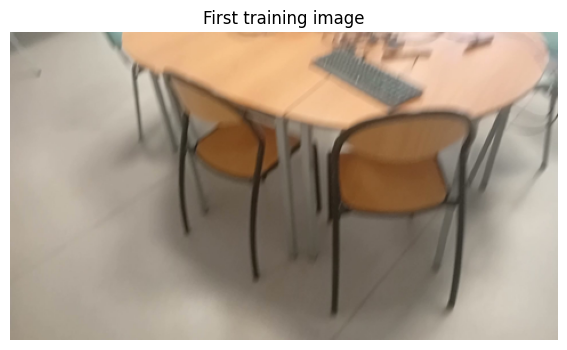

In [12]:
####################
# This cell defines the `get_rays` function, which is crucial for NeRF.
# It generates camera rays (origin and direction) for each pixel in an image.
# It then uses this function to load the dataset, transferring it to the
# specified device (GPU/CPU), and displays the first training image to verify
# successful loading.
####################
def get_rays(H, W, fx, fy, cx, cy, c2w, device):
    """Generates rays (origin and direction) for all pixels in an image.

    Args:
        H (int): Image height.
        W (int): Image width.
        fx (float): Focal length in x-direction.
        fy (float): Focal length in y-direction.
        cx (float): Principal point x-coordinate.
        cy (float): Principal point y-coordinate.
        c2w (torch.Tensor): Camera-to-world transformation matrix (4x4).
        device (torch.device): Device to store tensors.

    Returns:
        tuple: rays_o (torch.Tensor) - Ray origins (H*W, 3),
               rays_d (torch.Tensor) - Ray directions (H*W, 3).
    """
    # Create a grid of pixel coordinates (i, j)
    i, j = torch.meshgrid(
        torch.arange(W, device=device),
        torch.arange(H, device=device),
        indexing="xy" # Use 'xy' indexing for (width, height) order
    )
    # Calculate directions in camera coordinates
    # (i - cx) / fx, -(j - cy) / fy, -1.0
    dirs = torch.stack([(i - cx) / fx, -(j - cy) / fy, -torch.ones_like(i)], dim=-1)
    # Transform camera-to-world: rotate ray directions from camera to world space
    rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], dim=-1)
    # Ray origins are the camera position (last column of c2w) expanded to match ray_d shape
    rays_o = c2w[:3, 3].expand(rays_d.shape)
    return rays_o, rays_d

# --- Dataset Loading and Initial Visualization ---

# Load images, camera poses, intrinsics, and camera IDs from the specified dataset source
images, poses, intrinsics, camera_ids, H, W = load_dataset(DATASET_SOURCE, CONFIG["resize_factor"])

# Move all loaded tensors to the specified device (GPU/CPU)
images = images.to(DEVICE)
poses = poses.to(DEVICE)
intrinsics = intrinsics.to(DEVICE)
camera_ids = camera_ids.to(DEVICE)

# Print loaded dataset information
print("Loaded:", images.shape, poses.shape, intrinsics.shape, "H,W=", H, W)
print("Camera IDs:", torch.unique(camera_ids).tolist())
print("First intrinsics:", intrinsics[0].tolist())

# Display the first training image to visually confirm data loading
plt.figure(figsize=(8, 4))
plt.imshow(images[0].cpu().numpy()) # Convert torch tensor to numpy for matplotlib
plt.axis("off") # Hide axes for cleaner image display
plt.title("First training image")
plt.show()

## 2. Dataset Loading and Preprocessing

In [13]:
####################
# This cell defines the core NeRF model architecture and rendering functions.
# It includes:
# - PositionalEncoding: Transforms input coordinates into a higher-dimensional space.
# - NeRF (MLP): The neural network that predicts color and density for 3D points.
# - raw2outputs: Converts raw NeRF outputs (color and density) into a rendered image (RGB, depth, opacity).
# - sample_pdf: Implements hierarchical sampling for more efficient ray sampling.
# - run_network: Batches points through the NeRF model.
# - render_rays: Orchestrates the entire rendering process for a batch of rays, including coarse and fine sampling.
####################
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs):
        super().__init__()
        self.num_freqs = num_freqs
        # Output dimension is original + 2 * num_freqs * original (for sin and cos)
        self.out_dim = 3 * (2 * num_freqs + 1)

    def forward(self, x):
        out = [x]
        for i in range(self.num_freqs):
            freq = 2.0 ** i # Frequency for this level of encoding
            out.append(torch.sin(freq * x))
            out.append(torch.cos(freq * x))
        return torch.cat(out, dim=-1)

class NeRF(nn.Module):
    def __init__(self, pos_dim, dir_dim, hidden_dim=256, n_layers=8, skip_layer=4):
        super().__init__()
        self.skip_layer = skip_layer
        layers = []
        # Build the main MLP (Multi-Layer Perceptron) for position encoding
        for i in range(n_layers):
            if i == 0:
                in_dim = pos_dim # First layer input is positional encoding of position
            elif i == skip_layer: # Skip connection layer
                in_dim = hidden_dim + pos_dim # Concatenate original position encoding
            else:
                in_dim = hidden_dim # Subsequent layers take hidden_dim input
            layers.append(nn.Linear(in_dim, hidden_dim))
        self.pts_linears = nn.ModuleList(layers)

        # Output layers for density (sigma) and feature vector
        self.sigma_linear = nn.Linear(hidden_dim, 1) # Predicts density
        self.feature_linear = nn.Linear(hidden_dim, hidden_dim) # Outputs feature vector for color prediction

        # Output layers for color (RGB), dependent on view direction
        self.dir_linear = nn.Linear(hidden_dim + dir_dim, hidden_dim // 2) # Combines feature and direction encoding
        self.rgb_linear = nn.Linear(hidden_dim // 2, 3) # Predicts RGB color

    def forward(self, x, d):
        h = x # Initial input is positional encoding of position
        for i, layer in enumerate(self.pts_linears):
            if i == self.skip_layer:
                h = torch.cat([h, x], dim=-1) # Apply skip connection
            h = F.relu(layer(h)) # Apply linear layer and ReLU activation

        sigma = self.sigma_linear(h) # Predict density (sigma)
        feat = self.feature_linear(h) # Extract feature vector

        # Predict color based on feature vector and view direction encoding
        h_dir = F.relu(self.dir_linear(torch.cat([feat, d], dim=-1))) # Concatenate feature and direction, then linear+ReLU
        rgb = torch.sigmoid(self.rgb_linear(h_dir)) # Predict RGB and apply sigmoid for [0, 1] range
        return rgb, sigma

def raw2outputs(rgb, sigma, z_vals, rays_d):
    # Calculate distances between samples along each ray
    dists = z_vals[..., 1:] - z_vals[..., :-1]
    # Add a large distance for the last segment to prevent division by zero or issues with accumulation
    dists = torch.cat([dists, torch.full_like(dists[..., :1], 1e10)], dim=-1)
    # Multiply distances by the length of the ray direction vector to get actual distances
    dists = dists * torch.norm(rays_d[..., None, :], dim=-1)

    # Calculate alpha values (opacity) using raw sigma and distances
    alpha = 1.0 - torch.exp(-F.relu(sigma[..., 0]) * dists)
    # Calculate transmittance (how much light passes through up to each point)
    trans = torch.cumprod(torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], dim=-1), dim=-1)[..., :-1]
    # Calculate weights for each sample (contribution to the final pixel color)
    weights = alpha * trans

    # Rendered RGB color is the weighted sum of sample colors
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    # Rendered depth map is the weighted sum of sample depths
    depth_map = torch.sum(weights * z_vals, dim=-1)
    # Accumulated opacity (how opaque the ray is)
    acc_map = torch.sum(weights, dim=-1)
    return rgb_map, depth_map, acc_map, weights

def sample_pdf(bins, weights, n_samples, deterministic=False):
    # Add small epsilon to weights to avoid division by zero
    weights = weights + 1e-5
    # Normalize weights to form a Probability Density Function (PDF)
    pdf = weights / torch.sum(weights, dim=-1, keepdim=True)
    # Compute Cumulative Distribution Function (CDF)
    cdf = torch.cumsum(pdf, dim=-1)
    # Add 0 to the beginning of CDF
    cdf = torch.cat([torch.zeros_like(cdf[..., :1]), cdf], dim=-1)

    # Generate uniform samples (or deterministic for testing)
    if deterministic:
        u = torch.linspace(0.0, 1.0, n_samples, device=bins.device).expand(*cdf.shape[:-1], n_samples)
    else:
        u = torch.rand(*cdf.shape[:-1], n_samples, device=bins.device)

    # Find the bin indices corresponding to the sampled values in the CDF
    inds = torch.searchsorted(cdf, u.contiguous(), right=True)

    # Clamp indices to valid range
    below_cdf = torch.clamp(inds - 1, min=0, max=cdf.shape[-1] - 1)
    above_cdf = torch.clamp(inds, min=0, max=cdf.shape[-1] - 1)
    inds_cdf = torch.stack([below_cdf, above_cdf], dim=-1)
    cdf_g = torch.gather(cdf.unsqueeze(-2).expand(*inds_cdf.shape[:-1], cdf.shape[-1]), -1, inds_cdf)

    # Gather corresponding bin values
    below_bins = torch.clamp(inds - 1, min=0, max=bins.shape[-1] - 1)
    above_bins = torch.clamp(inds, min=0, max=bins.shape[-1] - 1)
    inds_bins = torch.stack([below_bins, above_bins], dim=-1)
    bins_g = torch.gather(bins.unsqueeze(-2).expand(*inds_bins.shape[:-1], bins.shape[-1]), -1, inds_bins)

    # Calculate fractional distance 't' within the bin
    denom = cdf_g[..., 1] - cdf_g[..., 0]
    denom = torch.where(denom < 1e-5, torch.ones_like(denom), denom) # Avoid division by zero
    t = (u - cdf_g[..., 0]) / denom
    # Interpolate to find the new sample points
    return bins_g[..., 0] + t * (bins_g[..., 1] - bins_g[..., 0])

def run_network(pts, view_dirs, model, pe_pos, pe_dir, chunk=65536):
    # Flatten points and directions for batch processing by the MLP
    pts_flat = pts.reshape(-1, 3)
    dirs_flat = view_dirs[:, None, :].expand_as(pts).reshape(-1, 3)

    # Apply positional encoding to points and directions
    encoded_pts = pe_pos(pts_flat)
    encoded_dirs = pe_dir(dirs_flat)

    rgbs, sigmas = [], []
    # Process data in chunks to manage GPU memory
    for i in range(0, encoded_pts.shape[0], chunk):
        rgb_chunk, sigma_chunk = model(encoded_pts[i:i + chunk], encoded_dirs[i:i + chunk])
        rgbs.append(rgb_chunk)
        sigmas.append(sigma_chunk)

    # Concatenate results and reshape back to original dimensions
    rgb = torch.cat(rgbs, dim=0).reshape(*pts.shape[:-1], 3)
    sigma = torch.cat(sigmas, dim=0).reshape(*pts.shape[:-1], 1)
    return rgb, sigma

def render_rays(rays_o, rays_d, model_coarse, model_fine, pe_pos, pe_dir, cfg, deterministic=False):
    n_rays = rays_o.shape[0]
    # Generate initial sample points along each ray (uniform sampling)
    z_vals = torch.linspace(cfg["near"], cfg["far"], cfg["n_samples"], device=rays_o.device).expand(n_rays, cfg["n_samples"])

    # Add perturbation to z_vals for training (non-deterministic sampling)
    if not deterministic:
        mids = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1]) # Midpoints between samples
        upper = torch.cat([mids, z_vals[..., -1:]], dim=-1)
        lower = torch.cat([z_vals[..., :1], mids], dim=-1)
        z_vals = lower + (upper - lower) * torch.rand_like(z_vals) # Sample uniformly within each segment

    # Calculate 3D points along the rays
    pts = rays_o[:, None, :] + rays_d[:, None, :] * z_vals[..., None]
    # Normalize ray directions for consistency
    view_dirs = rays_d / torch.norm(rays_d, dim=-1, keepdim=True)

    # Run the coarse model to get initial RGB and sigma values
    rgb_c, sigma_c = run_network(pts, view_dirs, model_coarse, pe_pos, pe_dir)
    # Convert raw outputs to rendered image components for the coarse model
    rgb_map_c, depth_c, acc_c, weights = raw2outputs(rgb_c, sigma_c, z_vals, rays_d)

    # Hierarchical sampling: if fine model is used
    if cfg["n_importance"] > 0:
        # Sample additional points based on weights from the coarse model
        z_mid = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1]) # Midpoints of coarse samples
        z_fine = sample_pdf(z_mid, weights[..., 1:-1].detach(), cfg["n_importance"], deterministic=deterministic)
        # Combine coarse and fine sample points and sort them
        z_vals_all, _ = torch.sort(torch.cat([z_vals, z_fine], dim=-1), dim=-1)
        # Calculate 3D points for all combined samples
        pts_f = rays_o[:, None, :] + rays_d[:, None, :] * z_vals_all[..., None]
        # Run the fine model with the combined samples
        rgb_f, sigma_f = run_network(pts_f, view_dirs, model_fine, pe_pos, pe_dir)
        # Convert raw outputs to rendered image components for the fine model
        rgb_map_f, depth_f, acc_f, _ = raw2outputs(rgb_f, sigma_f, z_vals_all, rays_d)
        return rgb_map_c, rgb_map_f, depth_c, depth_f, acc_c, acc_f

    # If no fine model, coarse output is duplicated for consistency
    return rgb_map_c, rgb_map_c, depth_c, depth_c, acc_c, acc_c

## 3. NeRF Model Definition and Core Functions

In [14]:
####################
# This cell initializes the NeRF models (coarse and fine) and their optimizer.
# It also builds a global cache of all rays and corresponding ground truth RGB values
# from the training images. This cache is used to efficiently sample rays during training.
####################
# Initialize positional encoding modules for position and direction
pe_pos = PositionalEncoding(CONFIG["L_pos"]).to(DEVICE)
pe_dir = PositionalEncoding(CONFIG["L_dir"]).to(DEVICE)

# Initialize the coarse and fine NeRF models
model_coarse = NeRF(pe_pos.out_dim, pe_dir.out_dim, CONFIG["hidden_dim"], CONFIG["n_layers"], CONFIG["skip_layer"]).to(DEVICE)
model_fine = NeRF(pe_pos.out_dim, pe_dir.out_dim, CONFIG["hidden_dim"], CONFIG["n_layers"], CONFIG["skip_layer"]).to(DEVICE)

# Initialize the Adam optimizer for both models
optimizer = torch.optim.Adam(list(model_coarse.parameters()) + list(model_fine.parameters()), lr=CONFIG["lr"])

@torch.no_grad()
def build_global_ray_cache(images, poses, intrinsics):
    """Pre-computes and caches all rays and their corresponding ground truth RGB values from the dataset."""
    rays_o_all, rays_d_all, rgbs_all = [], [], []
    # Iterate through each image in the dataset
    for i in trange(images.shape[0], desc="Caching rays"):
        fx, fy, cx, cy = intrinsics[i].tolist() # Get intrinsic parameters for the current image
        # Generate rays for all pixels in the current image
        rays_o_i, rays_d_i = get_rays(images.shape[1], images.shape[2], fx, fy, cx, cy, poses[i], DEVICE)
        # Reshape and append ray origins, directions, and ground truth RGBs to lists
        rays_o_all.append(rays_o_i.reshape(-1, 3))
        rays_d_all.append(rays_d_i.reshape(-1, 3))
        rgbs_all.append(images[i].reshape(-1, 3))
    # Concatenate all cached rays and RGBs into single tensors
    return torch.cat(rays_o_all, dim=0), torch.cat(rays_d_all, dim=0), torch.cat(rgbs_all, dim=0)

# Build the global ray cache once before training
all_rays_o, all_rays_d, all_rgbs = build_global_ray_cache(images, poses, intrinsics)
print("Ray cache shape:", all_rays_o.shape)

Caching rays:   0%|          | 0/149 [00:00<?, ?it/s]

Ray cache shape: torch.Size([19310400, 3])


## 4. Model Initialization and Ray Caching

Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Training complete


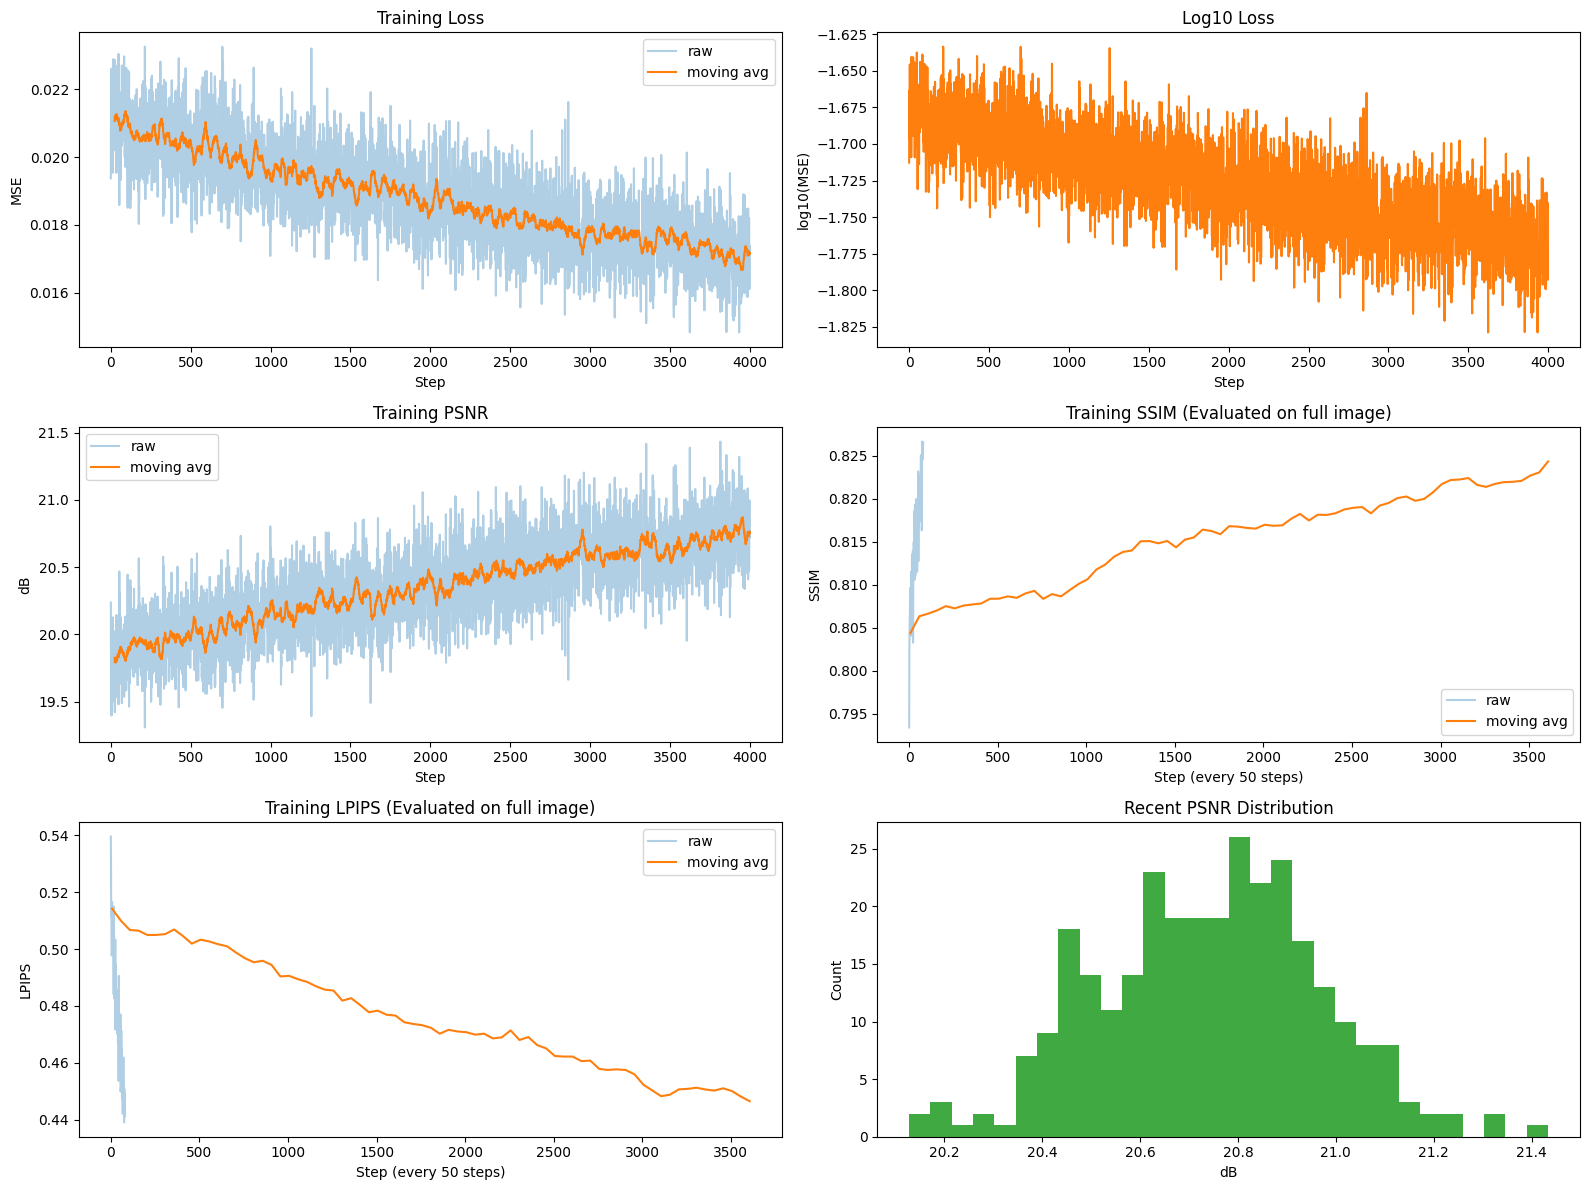

In [20]:
loss_history = []
psnr_history = []
ssim_history = [] # New: History for SSIM
lpips_history = [] # New: History for LPIPS
n_total = all_rays_o.shape[0] # Total number of rays in the cache

pbar = trange(CONFIG["max_steps"], desc="Training") # Progress bar for training steps
render_index = 0 # Use the first training image for periodic evaluation

for step in pbar:
    model_coarse.train() # Set models to training mode
    model_fine.train() # Set models to training mode

    # Randomly sample a batch of rays from the global cache
    idx = torch.randint(0, n_total, (CONFIG["n_rand"],), device=DEVICE)
    rays_o = all_rays_o[idx]
    rays_d = all_rays_d[idx]
    target_rgb = all_rgbs[idx] # Corresponding ground truth RGB for sampled rays

    # Render the sampled rays through both coarse and fine models
    rgb_c, rgb_f, _, _, _, _ = render_rays(
        rays_o, rays_d, model_coarse, model_fine, pe_pos, pe_dir, CONFIG, deterministic=False
    )

    # Calculate Mean Squared Error (MSE) loss for both coarse and fine renderings
    loss_c = F.mse_loss(rgb_c, target_rgb)
    loss_f = F.mse_loss(rgb_f, target_rgb)
    loss = loss_c + loss_f # Total loss is sum of coarse and fine losses

    optimizer.zero_grad(set_to_none=True) # Clear previous gradients
    loss.backward() # Perform backpropagation
    optimizer.step() # Update model parameters

    # Calculate PSNR (Peak Signal-to-Noise Ratio) from the fine model's loss
    psnr = -10.0 * torch.log10(loss_f.detach()) # Detach loss to prevent gradient calculation
    loss_history.append(loss.item())
    psnr_history.append(psnr.item())

    # Log training progress periodically and evaluate full image for SSIM/LPIPS
    if (step + 1) % CONFIG["log_every"] == 0:
        # Temporarily set models to evaluation mode for rendering a full image
        model_coarse.eval()
        model_fine.eval()
        with torch.no_grad():
            # Render the first training image to get evaluation metrics
            eval_recon_rgb, _, _ = render_full_image(poses[render_index], intrinsics[render_index], H, W)
        model_coarse.train() # Restore train mode
        model_fine.train()   # Restore train mode

        # Prepare images for SSIM and LPIPS (expected format is NCHW)
        eval_recon_rgb_perm = eval_recon_rgb.permute(2, 0, 1).unsqueeze(0) # (1, 3, H, W)
        gt_image_perm = images[render_index].permute(2, 0, 1).unsqueeze(0) # (1, 3, H, W)

        # Calculate SSIM
        ssim_val = tmF.structural_similarity_index_measure(
            eval_recon_rgb_perm, gt_image_perm, data_range=1.0
        ).item()
        ssim_history.append(ssim_val)

        # Calculate LPIPS (expects input in [-1, 1])
        lpips_val = lpips_model(
            eval_recon_rgb_perm * 2 - 1, # Normalize from [0,1] to [-1,1]
            gt_image_perm * 2 - 1
        ).item()
        lpips_history.append(lpips_val)

        # Update progress bar with new metrics
        pbar.set_postfix(loss=f"{loss.item():.5f}", psnr=f"{psnr.item():.2f}", ssim=f"{ssim_val:.3f}", lpips=f"{lpips_val:.3f}")

print("Training complete")

# Smoothed curves make convergence easier to inspect.
def moving_average(x, w=25):
    """Calculates a simple moving average for a list of values."""
    if len(x) < w:
        return np.array(x)
    return np.convolve(np.array(x), np.ones(w) / w, mode="valid")

# Calculate moving averages for all metrics for smoother plots
loss_ma = moving_average(loss_history, w=25)
psnr_ma = moving_average(psnr_history, w=25)
ssim_ma = moving_average(ssim_history, w=max(1, len(ssim_history) // 10)) # New: SSIM moving average
lpips_ma = moving_average(lpips_history, w=max(1, len(lpips_history) // 10)) # New: LPIPS moving average

# Plotting training progress - Adjusted for 6 subplots
plt.figure(figsize=(16, 12)) # Increased figure size for more plots

plt.subplot(3, 2, 1) # Subplot for raw and moving average loss
plt.plot(loss_history, alpha=0.35, label="raw")
if len(loss_ma) > 0:
    plt.plot(np.arange(len(loss_ma)) + (25 - 1), loss_ma, label="moving avg") # Adjust x-offset for MA
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.legend()

plt.subplot(3, 2, 2) # Subplot for log10 of loss
plt.plot(np.log10(np.array(loss_history) + 1e-12), color="tab:orange")
plt.title("Log10 Loss")
plt.xlabel("Step")
plt.ylabel("log10(MSE)")

plt.subplot(3, 2, 3) # Subplot for raw and moving average PSNR
plt.plot(psnr_history, alpha=0.35, label="raw")
if len(psnr_ma) > 0:
    plt.plot(np.arange(len(psnr_ma)) + (25 - 1), psnr_ma, label="moving avg") # Adjust x-offset for MA
plt.title("Training PSNR")
plt.xlabel("Step")
plt.ylabel("dB")
plt.legend()

plt.subplot(3, 2, 4) # New: Subplot for raw and moving average SSIM
plt.plot(ssim_history, alpha=0.35, label="raw")
if len(ssim_ma) > 0:
    plt.plot(np.arange(len(ssim_ma)) * CONFIG["log_every"] + (max(1, len(ssim_history) // 10) - 1), ssim_ma, label="moving avg") # Adjust x-offset for MA
plt.title("Training SSIM (Evaluated on full image)")
plt.xlabel(f"Step (every {CONFIG['log_every']} steps)")
plt.ylabel("SSIM")
plt.legend()

plt.subplot(3, 2, 5) # New: Subplot for raw and moving average LPIPS
plt.plot(lpips_history, alpha=0.35, label="raw")
if len(lpips_ma) > 0:
    plt.plot(np.arange(len(lpips_ma)) * CONFIG["log_every"] + (max(1, len(lpips_history) // 10) - 1), lpips_ma, label="moving avg") # Adjust x-offset for MA
plt.title("Training LPIPS (Evaluated on full image)")
plt.xlabel(f"Step (every {CONFIG['log_every']} steps)")
plt.ylabel("LPIPS")
plt.legend()

plt.subplot(3, 2, 6) # Subplot for histogram of recent PSNR values
plt.hist(psnr_history[-min(len(psnr_history), 300):], bins=30, color="tab:green", alpha=0.9)
plt.title("Recent PSNR Distribution")
plt.xlabel("dB")
plt.ylabel("Count")

plt.tight_layout() # Adjust layout to prevent overlapping elements
plt.show()

## 5. Training the NeRF Model

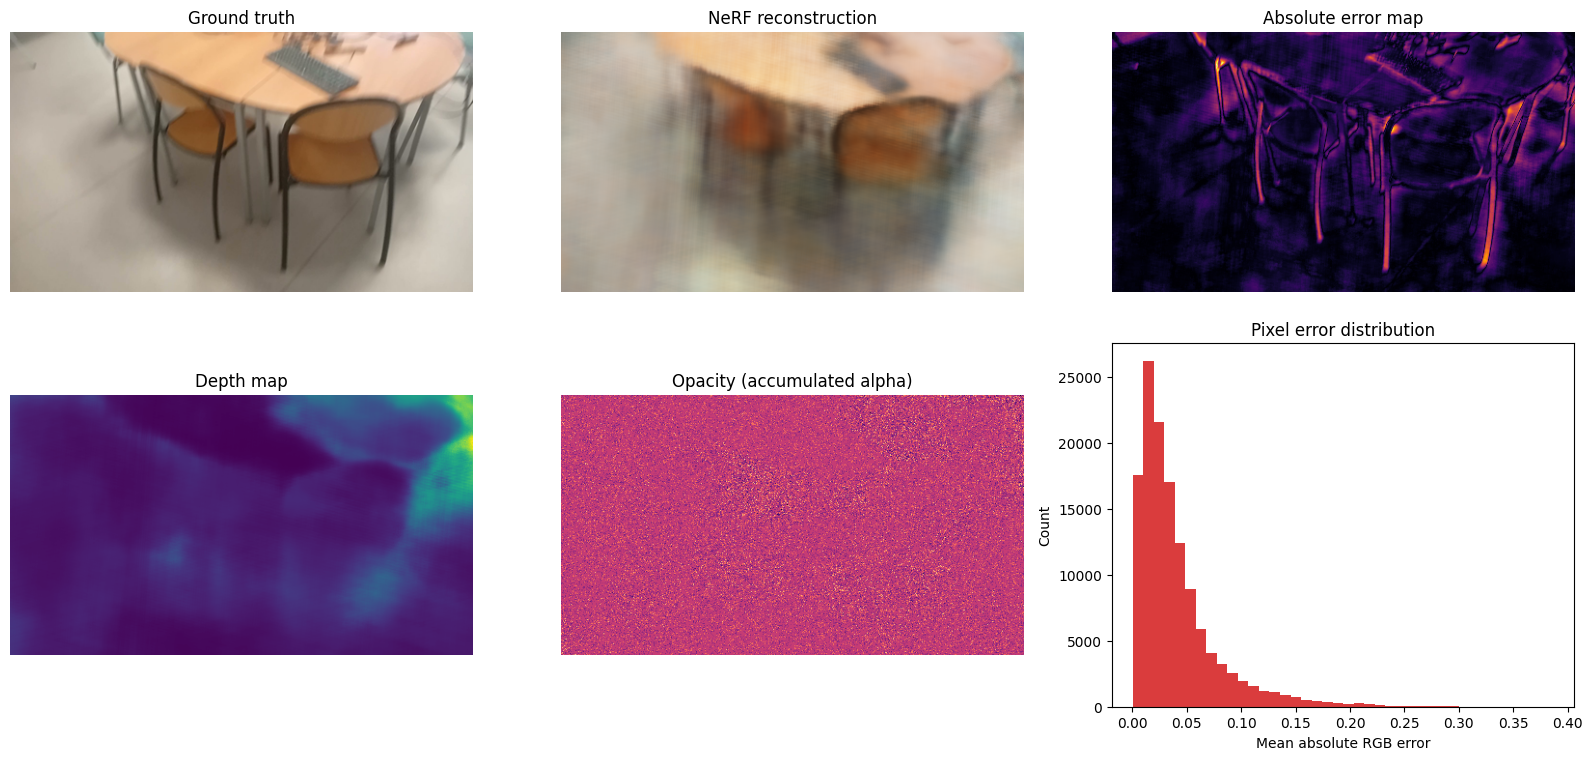

Full-image PSNR: 24.80 dB


AttributeError: 'NoneType' object has no attribute 'exists'

In [22]:
####################
# This cell handles the rendering and evaluation of the trained NeRF model.
# It defines a function to render a full image from a given camera pose,
# then uses this to reconstruct a training image, compute errors, and optionally
# render a novel view or another training view if a test set is not available.
# Finally, it saves the trained model's state for future use.
####################
@torch.no_grad()
def render_full_image(pose, intrinsics, H, W, chunk=8192):
    """Renders a full image from a given camera pose and intrinsics."""
    model_coarse.eval() # Set models to evaluation mode
    model_fine.eval()
    # Extract intrinsic parameters
    fx, fy, cx, cy = intrinsics.tolist() if torch.is_tensor(intrinsics) else intrinsics
    # Generate rays for all pixels in the image
    rays_o, rays_d = get_rays(H, W, fx, fy, cx, cy, pose, DEVICE)
    rays_o = rays_o.reshape(-1, 3)
    rays_d = rays_d.reshape(-1, 3)

    out_rgb = []
    out_depth = []
    out_acc = []
    # Render rays in chunks to manage memory
    for i in range(0, rays_o.shape[0], chunk):
        # Render current chunk of rays using the trained models (deterministic=True for rendering)
        _, rgb_f, _, depth_f, _, acc_f = render_rays(
            rays_o[i:i+chunk], rays_d[i:i+chunk],
            model_coarse, model_fine, pe_pos, pe_dir, CONFIG, deterministic=True
        )
        out_rgb.append(rgb_f)
        out_depth.append(depth_f)
        out_acc.append(acc_f)

    # Concatenate and reshape rendered outputs to form the full image
    rgb = torch.cat(out_rgb, dim=0).reshape(H, W, 3).clamp(0.0, 1.0) # Clamp RGB values to [0, 1]
    depth = torch.cat(out_depth, dim=0).reshape(H, W)
    acc = torch.cat(out_acc, dim=0).reshape(H, W)
    return rgb, depth, acc

# Choose a training image to reconstruct and evaluate
render_index = 0
# Render the chosen image using the trained NeRF model
recon, depth_map, acc_map = render_full_image(poses[render_index], intrinsics[render_index], H, W)
gt = images[render_index] # Ground truth image

# Calculate absolute error map between reconstruction and ground truth
abs_err = (recon - gt).abs().mean(dim=-1)

# Plotting reconstruction results
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1) # Ground truth image
plt.imshow(gt.cpu().numpy())
plt.title("Ground truth")
plt.axis("off")

plt.subplot(2, 3, 2) # NeRF reconstruction
plt.imshow(recon.cpu().numpy())
plt.title("NeRF reconstruction")
plt.axis("off")

plt.subplot(2, 3, 3) # Absolute error map
plt.imshow(abs_err.cpu().numpy(), cmap="inferno")
plt.title("Absolute error map")
plt.axis("off")

plt.subplot(2, 3, 4) # Rendered depth map
plt.imshow(depth_map.cpu().numpy(), cmap="viridis")
plt.title("Depth map")
plt.axis("off")

plt.subplot(2, 3, 5) # Rendered opacity (accumulated alpha)
plt.imshow(acc_map.cpu().numpy(), cmap="magma")
plt.title("Opacity (accumulated alpha)")
plt.axis("off")

plt.subplot(2, 3, 6) # Histogram of pixel errors
plt.hist(abs_err.detach().cpu().numpy().ravel(), bins=40, color="tab:red", alpha=0.9)
plt.title("Pixel error distribution")
plt.xlabel("Mean absolute RGB error")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Calculate and print PSNR for the reconstructed image
mse = F.mse_loss(recon, gt)
psnr = -10.0 * torch.log10(mse)
print(f"Full-image PSNR: {psnr.item():.2f} dB")

# --- Optional: Render novel view or another training view ---

# Check if a separate test JSON exists for novel view synthesis
if TEST_JSON.exists() and TEST_JSON.is_file():
    try:
        # Load test dataset and render a novel view
        test_images, test_poses, test_intrinsics, _, _, _ = load_dataset(TEST_JSON, CONFIG["resize_factor"])
        test_pose = test_poses[0].to(DEVICE)
        test_intrinsic = test_intrinsics[0].to(DEVICE)
        novel_rgb, novel_depth, novel_acc = render_full_image(test_pose, test_intrinsic, H, W)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(novel_rgb.cpu().numpy())
        plt.title("Novel view RGB")
        plt.axis("off")
        plt.subplot(1, 3, 2)
        plt.imshow(novel_depth.cpu().numpy(), cmap="viridis")
        plt.title("Novel view depth")
        plt.axis("off")
        plt.subplot(1, 3, 3)
        plt.imshow(novel_acc.cpu().numpy(), cmap="magma")
        plt.title("Novel view opacity")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    except FileNotFoundError as e:
        print("Skipped test render:", e)
# If no test JSON, render a second training view if available
elif images.shape[0] > 1:
    secondary_index = min(1, images.shape[0] - 1) # Choose a different training image
    secondary_rgb, secondary_depth, secondary_acc = render_full_image(
        poses[secondary_index], intrinsics[secondary_index], H, W
    )
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(secondary_rgb.cpu().numpy())
    plt.title(f"Secondary train view #{secondary_index}")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(secondary_depth.cpu().numpy(), cmap="viridis")
    plt.title("Secondary depth")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(secondary_acc.cpu().numpy(), cmap="magma")
    plt.title("Secondary opacity")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Save the trained model's state (config, model weights, optimizer state) to Google Drive
torch.save({
    "config": CONFIG,
    "model_coarse": model_coarse.state_dict(),
    "model_fine": model_fine.state_dict(),
    "optimizer": optimizer.state_dict()
}, ROOT / "nerf_checkpoint_minimal.pth")
print("Saved checkpoint: nerf_checkpoint_minimal.pth")

Full-image SSIM: 0.827
Full-image LPIPS: 0.449


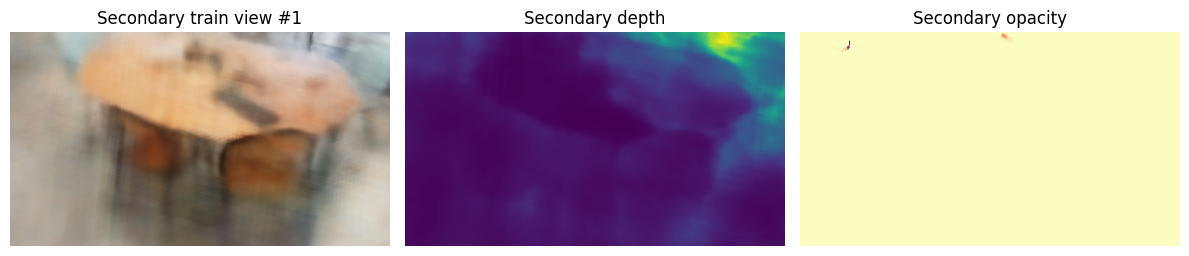

Secondary image SSIM: 0.755
Secondary image LPIPS: 0.540


In [23]:
# Calculate and print SSIM and LPIPS for the reconstructed image
recon_perm = recon.permute(2, 0, 1).unsqueeze(0)
gt_perm = gt.permute(2, 0, 1).unsqueeze(0)

ssim_full = tmF.structural_similarity_index_measure(recon_perm, gt_perm, data_range=1.0).item()
lpips_full = lpips_model(recon_perm * 2 - 1, gt_perm * 2 - 1).item()

print(f"Full-image SSIM: {ssim_full:.3f}")
print(f"Full-image LPIPS: {lpips_full:.3f}")

# --- Optional: Render novel view or another training view ---

# Check if a separate test JSON exists for novel view synthesis
if TEST_JSON is not None and TEST_JSON.exists() and TEST_JSON.is_file():
    try:
        # Load test dataset and render a novel view
        test_images, test_poses, test_intrinsics, _, _, _ = load_dataset(TEST_JSON, CONFIG["resize_factor"])
        test_pose = test_poses[0].to(DEVICE)
        test_intrinsic = test_intrinsics[0].to(DEVICE)
        novel_rgb, novel_depth, novel_acc = render_full_image(test_pose, test_intrinsic, H, W)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(novel_rgb.cpu().numpy())
        plt.title("Novel view RGB")
        plt.axis("off")
        plt.subplot(1, 3, 2)
        plt.imshow(novel_depth.cpu().numpy(), cmap="viridis")
        plt.title("Novel view depth")
        plt.axis("off")
        plt.subplot(1, 3, 3)
        plt.imshow(novel_acc.cpu().numpy(), cmap="magma")
        plt.title("Novel view opacity")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        # Calculate and print SSIM and LPIPS for the novel view
        novel_rgb_perm = novel_rgb.permute(2, 0, 1).unsqueeze(0)
        # If test_images exist and have a corresponding ground truth for the novel view, use it.
        # Otherwise, we can only evaluate against a dummy or assume no GT for novel views.
        # For now, we'll calculate SSIM/LPIPS for novel view if a corresponding GT is available, otherwise skip.
        # Assuming no direct GT for novel views, so skipping SSIM/LPIPS for this part unless specific GT is provided.
        print("SSIM and LPIPS for novel view are typically computed when ground truth is available.")

    except FileNotFoundError as e:
        print("Skipped test render:", e)
# If no test JSON, render a second training view if available
elif images.shape[0] > 1:
    secondary_index = min(1, images.shape[0] - 1) # Choose a different training image
    secondary_rgb, secondary_depth, secondary_acc = render_full_image(
        poses[secondary_index], intrinsics[secondary_index], H, W
    )
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(secondary_rgb.cpu().numpy())
    plt.title(f"Secondary train view #{secondary_index}")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(secondary_depth.cpu().numpy(), cmap="viridis")
    plt.title("Secondary depth")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(secondary_acc.cpu().numpy(), cmap="magma")
    plt.title("Secondary opacity")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Calculate and print SSIM and LPIPS for the secondary training view
    secondary_rgb_perm = secondary_rgb.permute(2, 0, 1).unsqueeze(0)
    gt_secondary_perm = images[secondary_index].permute(2, 0, 1).unsqueeze(0)

    ssim_secondary = tmF.structural_similarity_index_measure(secondary_rgb_perm, gt_secondary_perm, data_range=1.0).item()
    lpips_secondary = lpips_model(secondary_rgb_perm * 2 - 1, gt_secondary_perm * 2 - 1).item()

    print(f"Secondary image SSIM: {ssim_secondary:.3f}")
    print(f"Secondary image LPIPS: {lpips_secondary:.3f}")

## 7. Generate Video/GIF of Novel Views

In [27]:
####################
# This cell defines a function to generate a circular camera trajectory.
# This trajectory will be used to render a sequence of novel views,
# demonstrating the NeRF model's ability to synthesize new perspectives.
####################
import imageio
from IPython.display import HTML, display
from tqdm.auto import tqdm

def generate_circular_poses(original_poses, num_frames=60, orbit_radius=None, orbit_center=None, orbit_axis='z', orbit_val=None, arc_angle_rad=2*np.pi):
    """Generates a circular trajectory of camera poses around a specified axis and center.

    Args:
        original_poses (torch.Tensor): Existing training camera poses (N, 4, 4). Used for default estimations.
        num_frames (int): Number of frames for the video.
        orbit_radius (float, optional): Radius of the circular orbit. If None, estimated from original_poses.
        orbit_center (torch.Tensor, optional): The 3D point that defines the center of the orbit AND what the camera looks at. If None, it's estimated from original_poses.
        orbit_axis (str): The axis around which the camera orbits ('x', 'y', or 'z'). Default is 'z'.
        orbit_val (float, optional): The fixed coordinate value along the `orbit_axis`. E.g., if `orbit_axis='z'`, this is the fixed Z-coordinate of the orbit. If None, it's estimated from `orbit_center`.
        arc_angle_rad (float): Total angular sweep of the trajectory in radians. Default is 2*pi for a full circle.

    Returns:
        torch.Tensor: A tensor of generated camera-to-world (c2w) matrices (num_frames, 4, 4).
    """
    device = original_poses.device

    # Estimate orbit_center if not provided
    if orbit_center is None:
        orbit_center = original_poses[:, :3, 3].mean(dim=0).to(device) # Average camera position
    else:
        orbit_center = orbit_center.to(device)

    # Estimate orbit_radius if not provided
    if orbit_radius is None:
        distances = torch.norm(original_poses[:, :3, 3] - orbit_center, dim=-1)
        orbit_radius = distances.max().item() * 1.5
        if orbit_radius < 0.5:
            orbit_radius = 2.0

    generated_poses = []
    up_vector = torch.tensor([0.0, 0.0, 1.0], device=device) # World Z is generally considered 'up'

    for i in range(num_frames):
        angle = arc_angle_rad * (i / num_frames)

        # Initialize camera coordinates with orbit_center values
        cam_x, cam_y, cam_z = orbit_center[0].item(), orbit_center[1].item(), orbit_center[2].item()

        # Determine fixed coordinate and varying coordinates based on orbit_axis
        if orbit_axis == 'z': # Orbit in XY plane, Z is constant
            fixed_z = orbit_val if orbit_val is not None else orbit_center[2].item()
            cam_x = orbit_center[0] + orbit_radius * np.cos(angle)
            cam_y = orbit_center[1] + orbit_radius * np.sin(angle)
            cam_z = fixed_z
        elif orbit_axis == 'y': # Orbit in XZ plane, Y is constant
            fixed_y = orbit_val if orbit_val is not None else orbit_center[1].item()
            cam_x = orbit_center[0] + orbit_radius * np.cos(angle)
            cam_y = fixed_y
            cam_z = orbit_center[2] + orbit_radius * np.sin(angle)
        elif orbit_axis == 'x': # Orbit in YZ plane, X is constant
            fixed_x = orbit_val if orbit_val is not None else orbit_center[0].item()
            cam_x = fixed_x
            cam_y = orbit_center[1] + orbit_radius * np.cos(angle)
            cam_z = orbit_center[2] + orbit_radius * np.sin(angle)
        else:
            raise ValueError(f"Unsupported orbit_axis: {orbit_axis}. Choose 'x', 'y', or 'z'.")

        camera_position = torch.tensor([cam_x, cam_y, cam_z], device=device)

        # Camera always looks at the orbit_center
        z_axis = F.normalize(orbit_center - camera_position, dim=0)

        # Construct rotation matrix
        # X-axis of camera is cross product of up_vector and z_axis
        x_axis = F.normalize(torch.cross(up_vector, z_axis), dim=0)
        # Y-axis of camera is cross product of z_axis and x_axis
        y_axis = F.normalize(torch.cross(z_axis, x_axis), dim=0)
        R = torch.stack([x_axis, y_axis, z_axis], dim=1)

        c2w = torch.eye(4, device=device)
        c2w[:3, :3] = R
        c2w[:3, 3] = camera_position

        generated_poses.append(c2w)

    return torch.stack(generated_poses)

In [28]:
####################
# This cell renders a sequence of images along a generated circular camera path
# and then compiles them into an animated GIF. This visually demonstrates the
# 3D reconstruction capabilities of the trained NeRF model by showing novel views.
####################

# --- Generate a horizontal orbit (around Z-axis) ---
num_video_frames = 15 # Fewer frames for faster generation
video_poses_horizontal = generate_circular_poses(
    poses,
    num_video_frames,
    orbit_radius=2.5,
    orbit_val=1.5, # Fixed Z-coordinate for horizontal orbit
    arc_angle_rad=np.pi/2, # 90-degree arc
    orbit_axis='z'
)

# Prepare to store rendered frames for horizontal orbit
rendered_frames_horizontal = []

# Render each frame for horizontal orbit
for i in tqdm(range(num_video_frames), desc="Rendering horizontal video frames"):
    # Render the full image for the current pose
    rgb_frame, _, _ = render_full_image(video_poses_horizontal[i], intrinsics[0], H, W)
    # Convert the PyTorch tensor to a NumPy array and then to uint8 for imageio
    rendered_frames_horizontal.append((rgb_frame.cpu().numpy() * 255).astype(np.uint8))

# Save the rendered frames as a GIF
gif_path_horizontal = ROOT / "nerf_novel_view_horizontal.gif"
imageio.mimsave(gif_path_horizontal, rendered_frames_horizontal, fps=20) # fps controls playback speed
print(f"Generated horizontal GIF saved to: {gif_path_horizontal}")


# --- Generate a vertical orbit (around Y-axis) ---
video_poses_vertical = generate_circular_poses(
    poses,
    num_video_frames,
    orbit_radius=2.5,
    orbit_val=0.0, # Fixed Y-coordinate (or estimated from orbit_center if None)
    arc_angle_rad=np.pi/2, # 90-degree arc
    orbit_axis='y' # Orbit around the Y-axis
)

# Prepare to store rendered frames for vertical orbit
rendered_frames_vertical = []

# Render each frame for vertical orbit
for i in tqdm(range(num_video_frames), desc="Rendering vertical video frames"):
    rgb_frame, _, _ = render_full_image(video_poses_vertical[i], intrinsics[0], H, W)
    rendered_frames_vertical.append((rgb_frame.cpu().numpy() * 255).astype(np.uint8))

# Save the rendered frames as a GIF
gif_path_vertical = ROOT / "nerf_novel_view_vertical.gif"
imageio.mimsave(gif_path_vertical, rendered_frames_vertical, fps=20)
print(f"Generated vertical GIF saved to: {gif_path_vertical}")

Rendering horizontal video frames:   0%|          | 0/15 [00:00<?, ?it/s]

Generated horizontal GIF saved to: /content/3DReconstruction_DLProject/nerf_novel_view_horizontal.gif
Displaying generated horizontal GIF:


Rendering vertical video frames:   0%|          | 0/15 [00:00<?, ?it/s]

Generated vertical GIF saved to: /content/3DReconstruction_DLProject/nerf_novel_view_vertical.gif
Displaying generated vertical GIF:
